2026-03-25 09:55:53.755514: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774432553.979177      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774432554.039523      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774432554.571799      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774432554.571847      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774432554.571851      55 computation_placer.cc:177] computation placer alr

Indexing slices for Training...
Balanced Dataset: 2067 Tumor / 2067 Healthy
Indexing slices for Testing...


I0000 00:00:1774432645.564933      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Starting ResNet-50 Training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1774432767.381824     129 service.cc:152] XLA service 0x7f14700027c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774432767.381870     129 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774432775.267099     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/259 ━━━━━━━━━━━━━━━━━━━━ 6:16:01 87s/step - accuracy: 0.5625 - loss: 0.6594 - recall: 0.8750

I0000 00:00:1774432799.339152     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


259/259 ━━━━━━━━━━━━━━━━━━━━ 1202s 4s/step - accuracy: 0.6697 - loss: 0.5878 - recall: 0.7377 - val_accuracy: 0.8815 - val_loss: 0.5884 - val_recall: 0.0468
Epoch 2/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 1095s 4s/step - accuracy: 0.8814 - loss: 0.2889 - recall: 0.9366 - val_accuracy: 0.8510 - val_loss: 0.4461 - val_recall: 0.1426
Epoch 3/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 1058s 4s/step - accuracy: 0.9662 - loss: 0.1219 - recall: 0.9870 - val_accuracy: 0.8230 - val_loss: 0.4116 - val_recall: 0.3617
Epoch 4/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 1097s 4s/step - accuracy: 0.9955 - loss: 0.0408 - recall: 0.9981 - val_accuracy: 0.5880 - val_loss: 1.1717 - val_recall: 0.7936
Epoch 5/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 1085s 4s/step - accuracy: 0.9996 - loss: 0.0118 - recall: 0.9997 - val_accuracy: 0.5496 - val_loss: 1.8985 - val_recall: 0.9255
Epoch 6/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 1104s 4s/step - accuracy: 0.9999 - loss: 0.0056 - recall: 0.9997 - val_accuracy: 0.6139 - val_loss: 1.8428 - val_recall: 0.9383
Epo

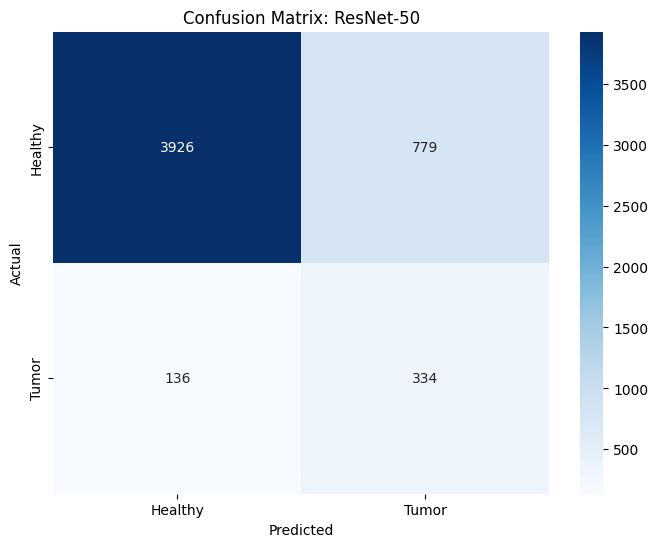


Generating ROC Curve...


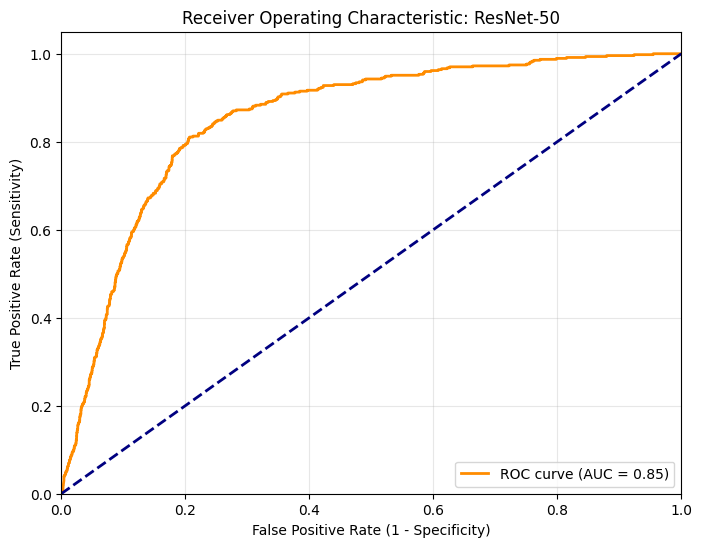

Final AUC Score: 0.8519


In [1]:
import os
import numpy as np
import cv2
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import Sequence
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. CONFIGURATION ---
IMG_SIZE = 224
BATCH_SIZE = 16
# Update these paths if your Kaggle dataset structure changes
BASE_PATH = "/kaggle/input/datasets/rksrank1/pancreatic-cancer/Task07_Pancreas"
IMAGE_DIR = os.path.join(BASE_PATH, "imagesTr")
MASK_DIR = os.path.join(BASE_PATH, "labelsTr")

# --- 2. DATA SEQUENCE (Preprocessing & Balancing) ---
class PancreasDataSequence(Sequence):
    def __init__(self, patient_files, batch_size=BATCH_SIZE, is_training=True):
        self.patient_files = patient_files
        self.batch_size = batch_size
        self.is_training = is_training
        self.samples = self._prepare_balanced_index()

    def _prepare_balanced_index(self):
        tumor_slices, healthy_slices = [], []
        print(f"Indexing slices for {'Training' if self.is_training else 'Testing'}...")
        
        for file in self.patient_files:
            mask_path = os.path.join(MASK_DIR, file)
            mask_vol = nib.load(mask_path).get_fdata()
            for i in range(mask_vol.shape[2]):
                # Class 2 is tumor in Task07 dataset
                if np.any(mask_vol[:, :, i] == 2):
                    tumor_slices.append((file, i, 1))
                else:
                    healthy_slices.append((file, i, 0))
        
        if self.is_training:
            # Randomly undersample healthy slices to match tumor slice count
            np.random.shuffle(healthy_slices)
            healthy_slices = healthy_slices[:len(tumor_slices)]
            print(f"Balanced Dataset: {len(tumor_slices)} Tumor / {len(healthy_slices)} Healthy")
        
        all_samples = tumor_slices + healthy_slices
        np.random.shuffle(all_samples)
        return all_samples

    def __len__(self):
        return int(np.ceil(len(self.samples) / self.batch_size))

    def __getitem__(self, idx):
        batch = self.samples[idx * self.batch_size : (idx + 1) * self.batch_size]
        X, y = [], []
        
        for file, slice_idx, label in batch:
            img_vol = nib.load(os.path.join(IMAGE_DIR, file)).get_fdata()
            slice_img = img_vol[:, :, slice_idx]
            
            # --- MEDICAL PREPROCESSING (Unified across all 6 models) ---
            slice_img = np.clip(slice_img, -100, 200) # Hounsfield Windowing
            slice_img = (slice_img + 100) / 300.0     # Normalization
            slice_img = cv2.resize(slice_img, (IMG_SIZE, IMG_SIZE))
            slice_img = np.stack([slice_img]*3, axis=-1) # Pseudo-RGB for ResNet
            
            X.append(slice_img)
            y.append(label)
        return np.array(X), np.array(y)

# --- 3. BUILD RESNET-50 ---
def build_resnet50():
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base_model.trainable = True # Fine-tune for CT feature extraction
    
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x) 
    x = Dense(256, activation='relu')(x) 
    output = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(optimizer=Adam(learning_rate=1e-5), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])
    return model

# --- 4. RUN TRAINING & EVALUATION ---
all_files = sorted([f for f in os.listdir(IMAGE_DIR) 
                    if (f.endswith(".nii") or f.endswith(".nii.gz")) 
                    and not f.startswith(".")])

if len(all_files) == 0:
    print(f"ERROR: No files found in {IMAGE_DIR}. Check your dataset path.")
else:
    train_f, test_f = train_test_split(all_files, test_size=0.2, random_state=42)

    train_seq = PancreasDataSequence(train_f, is_training=True)
    test_seq = PancreasDataSequence(test_f, is_training=False)

    resnet_model = build_resnet50()
    print("\nStarting ResNet-50 Training...")
    resnet_model.fit(train_seq, validation_data=test_seq, epochs=10)

    # --- FINAL EVALUATION ---
    print("\nEvaluating ResNet-50...")
    y_true, y_pred = [], []
    for i in range(len(test_seq)):
        xb, yb = test_seq[i]
        preds = resnet_model.predict(xb, verbose=0)
        y_true.extend(yb)
        y_pred.extend((preds > 0.5).astype(int).flatten())

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['Healthy', 'Tumor']))

    # Confusion Matrix Visualization
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Healthy', 'Tumor'], yticklabels=['Healthy', 'Tumor'])
    plt.title('Confusion Matrix: ResNet-50')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


# --- 5. ROC CURVE & AUC SCORE ---
from sklearn.metrics import roc_curve, auc

print("\nGenerating ROC Curve...")

# 1. Get the raw probabilities (required for ROC)
y_probs = []
y_true_roc = []

for i in range(len(test_seq)):
    xb, yb = test_seq[i]
    # Predict raw probability (0.0 to 1.0)
    batch_probs = resnet_model.predict(xb, verbose=0)
    y_probs.extend(batch_probs.flatten())
    y_true_roc.extend(yb)

# 2. Calculate metrics
fpr, tpr, thresholds = roc_curve(y_true_roc, y_probs)
roc_auc = auc(fpr, tpr)

# 3. Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic: ResNet-50')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Final AUC Score: {roc_auc:.4f}")